# Visualize Data from Elevator Panels Dataset

In [1]:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
from typing import List
import numpy as np
import os, json, cv2, random
import matplotlib.pyplot as plt
%matplotlib inline

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.utils.visualizer import ColorMode

from train import register_dataset

/home/abhinavchadaga/cs/fri_II/final_project/.venv/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path_to_dataset = "/home/abhinavchadaga/cs/fri_II/final_project/datasets/elevator_panels"

### Register Custom Dataset

In [3]:
DatasetCatalog.register("elevators", lambda: register_dataset(path_to_dataset))
MetadataCatalog.get("elevators").thing_classes = ["button", "label", "not button"]

dataset: List[dict] = DatasetCatalog.get("elevators")
print(f"number of objects: {len(dataset)}")

number of objects: 92


### Select 3 Random Objects from Dataset and Visualize Boxes and Masks

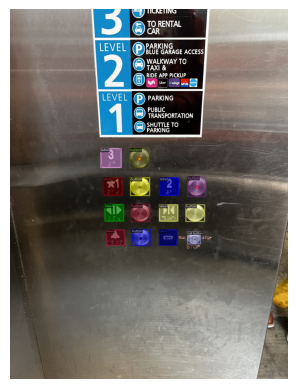

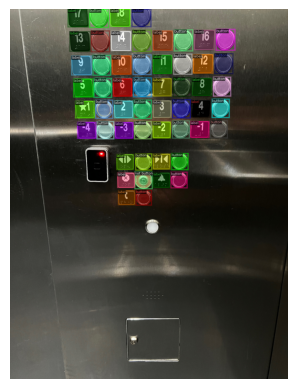

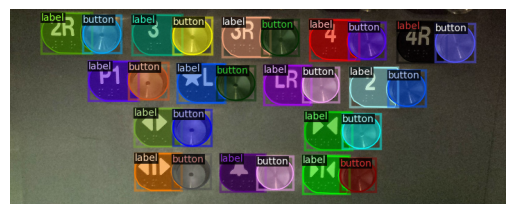

In [4]:
for d in random.sample(dataset, 3):
    img = cv2.imread(d["file_name"])
    visualizer = Visualizer(img[:, :, ::-1], metadata=MetadataCatalog.get("elevators"), scale=0.5, instance_mode=ColorMode.IMAGE)
    out = visualizer.draw_dataset_dict(d)
    plt.imshow(out.get_image())
    plt.axis("off")
    plt.show()